# 01 — Khảo sát dữ liệu (EDA)

**Mục tiêu.** Kiểm tra toàn vẹn `data/creditcard.csv`, sinh đủ 8 biểu đồ bắt buộc ở
[02 §9](../docs/02-dac-ta-du-lieu.md), và trả lời cho mỗi biểu đồ **một câu hỏi cụ thể**.
Không vẽ cho đủ số lượng — mỗi hình phải đổi được thành một quyết định thiết kế về sau.

**Việc tương ứng:** T-11, T-12, T-13 trong [TASKS.md](../TASKS.md).

**Cách chạy.** Từ kernel sạch, chạy `Run All`. Notebook không phụ thuộc trạng thái nào bên
ngoài ngoài `data/creditcard.csv`. Toàn bộ hình lưu vào `reports/figures/` với tiền tố `01_`.
Thời gian chạy khoảng 2–4 phút, phần lớn nằm ở t-SNE (hình 8).

**Điều cần nhớ trước khi đọc số.** Lớp dương chiếm 0,17%. Mọi giá trị trung bình, mọi tương
quan, mọi biểu đồ đếm số lượng đều bị lớp âm áp đảo. Nguyên tắc xuyên suốt notebook này:
**luôn vẽ tỷ lệ, không vẽ số lượng tuyệt đối**, và luôn tách hai lớp ra.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src import plots
from src.config import FIGURES_DIR, RANDOM_STATE, TARGET
from src.data import add_hour, class_balance, load_data, load_prepared
from src.features import RAW_REQUIRED_COLUMNS, V_COLUMNS

%matplotlib inline
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

# Sổ ghi hình: mỗi hình lưu ra đĩa đều phải kèm một câu hỏi và một câu trả lời.
# Ô kiểm tra ở mục 10 đối chiếu lại sổ này — đó là cách chứng minh T-12 và T-13 đã đạt.
SO_GHI_HINH: dict[str, dict] = {}


def luu_hinh(fig, ten_tep, cau_hoi, tra_loi):
    # Lưu figure vào reports/figures/ kèm câu hỏi mà nó trả lời.
    # Cố ý KHÔNG trả về fig: backend inline đã tự hiện hình ở cuối ô, trả thêm
    # sẽ khiến mỗi biểu đồ bị nhúng hai lần vào notebook.
    duong_dan = plots.save_fig(fig, ten_tep)
    SO_GHI_HINH[ten_tep] = {"fig": fig, "cau_hoi": cau_hoi, "tra_loi": tra_loi}
    print(f"đã lưu {duong_dan.relative_to(ROOT)}")


print("thư mục hình:", FIGURES_DIR.relative_to(ROOT))

thư mục hình: reports\figures


---
## 1. Toàn vẹn dữ liệu

`load_prepared()` làm đúng ba bước theo thứ tự bắt buộc của DS-20: **nạp → kiểm tra toàn vẹn
→ loại dòng trùng lặp**. Thứ tự này không đổi được. Loại trùng lặp *sau* khi chia tập sẽ để
cùng một dòng rơi vào cả tập huấn luyện lẫn tập kiểm thử — một rò rỉ nhẹ nhưng có thật, và
rất khó phát hiện về sau.

In [2]:
df, bao_cao = load_prepared()

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.


In [3]:
print("Đối chiếu với kỳ vọng ở 02 §6")
print("-" * 48)
print(f"số dòng thô          : {bao_cao.n_rows:,}       (kỳ vọng 284.807)")
print(f"số cột               : {bao_cao.n_columns}            (kỳ vọng 31)")
print(f"ô thiếu giá trị      : {bao_cao.n_missing_cells:,}            (kỳ vọng 0)")
print(f"dòng trùng lặp       : {bao_cao.n_duplicates:,}        (kỳ vọng khoảng 1.081)")
print(f"mẫu gian lận thô     : {bao_cao.n_fraud:,}          (kỳ vọng 492)")
print(f"đạt kiểm tra toàn vẹn: {bao_cao.ok}")

Đối chiếu với kỳ vọng ở 02 §6
------------------------------------------------
số dòng thô          : 284,807       (kỳ vọng 284.807)
số cột               : 31            (kỳ vọng 31)
ô thiếu giá trị      : 0            (kỳ vọng 0)
dòng trùng lặp       : 1,081        (kỳ vọng khoảng 1.081)
mẫu gian lận thô     : 492          (kỳ vọng 492)
đạt kiểm tra toàn vẹn: True


In [4]:
n_dong = len(df)
n_gian_lan = int(df[TARGET].sum())
ty_le_duong = n_gian_lan / n_dong

print(f"Sau khi loại trùng lặp: {n_dong:,} dòng, {n_gian_lan} gian lận "
      f"({ty_le_duong:.4%}), tức 1 trên {n_dong / n_gian_lan:.0f}.")
print(f"Trùng lặp đã loại     : {bao_cao.n_duplicates:,} dòng "
      f"({bao_cao.n_duplicates / bao_cao.n_rows:.3%}), "
      f"trong đó {bao_cao.n_fraud - n_gian_lan} mẫu gian lận.")
print()
print("Hệ quả kéo theo:")
print(f"  mô hình rỗng luôn trả 0 → accuracy {1 - ty_le_duong:.4%}")
print(f"  đường cơ sở PR-AUC      → {ty_le_duong:.5f}")
print(f"  tập kiểm thử 20%        → khoảng {round(n_gian_lan * 0.2)} mẫu gian lận, "
      f"bắt hụt 1 mẫu là mất {1 / round(n_gian_lan * 0.2):.2%} recall")

Sau khi loại trùng lặp: 283,726 dòng, 473 gian lận (0.1667%), tức 1 trên 600.
Trùng lặp đã loại     : 1,081 dòng (0.380%), trong đó 19 mẫu gian lận.

Hệ quả kéo theo:
  mô hình rỗng luôn trả 0 → accuracy 99.8333%
  đường cơ sở PR-AUC      → 0.00167
  tập kiểm thử 20%        → khoảng 95 mẫu gian lận, bắt hụt 1 mẫu là mất 1.05% recall


**Ghi nhận trùng lặp (T-11).** Đúng **1.081 dòng trùng lặp hoàn toàn** như 02 §6 dự báo,
chiếm 0,380% dữ liệu, trong đó **19 dòng thuộc lớp gian lận**. Sau khi loại còn
**283.726 dòng / 473 gian lận**, tỷ lệ dương giảm nhẹ từ 0,173% xuống **0,167%** (1 trên 600).

Hai con số này phải đi vào báo cáo, vì mọi bảng kết quả về sau đều tính trên 283.726 dòng chứ
không phải 284.807 — người đọc đối chiếu với trang Kaggle sẽ thấy lệch nếu ta không nói rõ.

Mất 19 mẫu dương trên tổng 492 là **3,9% số nhãn quý giá**, nhưng đây là cái giá bắt buộc:
giữ lại thì tập kiểm thử chứa dòng y hệt dòng trong tập huấn luyện, và PR-AUC báo cáo sẽ cao
hơn thực tế mà không ai biết.

### 1.1 Đối chiếu số liệu thô với số liệu sau khi loại trùng lặp

Các mốc quen thuộc của bộ dữ liệu này — tỷ lệ gian lận lúc 2 giờ sáng, trung vị `Amount`,
số giao dịch gian lận có `Amount = 0` — thường được trích từ **dữ liệu thô**. Pipeline của dự
án chạy trên **dữ liệu đã loại trùng lặp**, nên hai bộ số lệch nhau chút ít.

Ô dưới in cả hai cạnh nhau để báo cáo không bao giờ trộn nhầm. Đây là lần **duy nhất**
notebook đọc lại tệp thô; xong ô này biến `tho` được giải phóng khỏi bộ nhớ.

In [5]:
tho = load_data()


def ba_moc(khung):
    theo_gio = add_hour(khung).groupby("hour")[TARGET].agg(["size", "sum"])
    ty_le_gio = theo_gio["sum"] / theo_gio["size"]
    return {
        "tỷ lệ gian lận lúc 2h": ty_le_gio.loc[2],
        "tỷ lệ gian lận lúc 10h": ty_le_gio.loc[10],
        "trung vị Amount (gian lận)": khung.loc[khung[TARGET] == 1, "Amount"].median(),
        "trung vị Amount (hợp lệ)": khung.loc[khung[TARGET] == 0, "Amount"].median(),
        "trung bình Amount (gian lận)": khung.loc[khung[TARGET] == 1, "Amount"].mean(),
        "trung bình Amount (hợp lệ)": khung.loc[khung[TARGET] == 0, "Amount"].mean(),
        "số gian lận có Amount = 0": int(((khung["Amount"] == 0) & (khung[TARGET] == 1)).sum()),
        "tương quan Pearson của V17": khung["V17"].corr(khung[TARGET]),
    }


doi_chieu = pd.DataFrame({"dữ liệu thô": ba_moc(tho), "sau khi loại trùng lặp": ba_moc(df)})
doi_chieu["chênh lệch"] = doi_chieu["sau khi loại trùng lặp"] - doi_chieu["dữ liệu thô"]
display(doi_chieu.round(4))

del tho

,dữ liệu thô,sau khi loại trùng lặp,chênh lệch
tỷ lệ gian lận lúc 2h,0.0171,0.0145,-0.0026
tỷ lệ gian lận lúc 10h,0.0005,0.0005,0.0000
trung vị Amount (gian lận),9.2500,9.8200,0.5700
trung vị Amount (hợp lệ),22.0000,22.0000,0.0000
trung bình Amount (gian lận),122.2113,123.8719,1.6605
trung bình Amount (hợp lệ),88.2910,88.4136,0.1226
số gian lận có Amount = 0,27.0000,25.0000,-2.0000
tương quan Pearson của V17,-0.3265,-0.3135,0.0130


**Kết luận của bảng đối chiếu.** Hướng của cả ba phát hiện giữ nguyên, chỉ độ lớn nhích nhẹ.
Quy ước cho toàn bộ dự án: **mọi con số trong báo cáo lấy từ cột "sau khi loại trùng lặp"**,
vì đó là dữ liệu mà mô hình thực sự nhìn thấy. Khi cần trích con số thô để so với tài liệu
bên ngoài thì phải nói rõ đó là số thô.

In [6]:
print("Kiểu dữ liệu và miền giá trị")
tom_tat = pd.DataFrame({
    "kiểu": df.dtypes.astype(str),
    "nhỏ nhất": df.min(numeric_only=True),
    "trung vị": df.median(numeric_only=True),
    "lớn nhất": df.max(numeric_only=True),
    "số ô thiếu": df.isna().sum(),
})
display(tom_tat.loc[["Time", "V1", "V17", "Amount", "Class"]].round(3))

print()
print(f"Hợp đồng dữ liệu vào có {len(RAW_REQUIRED_COLUMNS)} cột bắt buộc (02 §5); "
      f"đủ cả {len(RAW_REQUIRED_COLUMNS)}: "
      f"{all(c in df.columns for c in RAW_REQUIRED_COLUMNS)}")
print(f"Cửa sổ quan sát: {df['Time'].max() / 86_400:.2f} ngày "
      f"({df['Time'].min():.0f} → {df['Time'].max():,.0f} giây)")

Kiểu dữ liệu và miền giá trị


,kiểu,nhỏ nhất,trung vị,lớn nhất,số ô thiếu
Time,float64,0.000,84692.500,172792.000,0
V1,float64,-56.408,0.020,2.455,0
V17,float64,-25.163,-0.066,9.254,0
Amount,float64,0.000,22.000,25691.160,0
Class,int64,0.000,0.000,1.000,0



Hợp đồng dữ liệu vào có 30 cột bắt buộc (02 §5); đủ cả 30: True
Cửa sổ quan sát: 2.00 ngày (0 → 172,792 giây)


---
## 2. Hình 1 — Phân bố nhãn

> **Câu hỏi:** Mất cân bằng đến mức nào, và nó buộc ta phải bỏ chỉ số nào?

,count,ratio,one_in
Class,,,
0,283253,0.998333,1.0
1,473,0.001667,599.8


đã lưu reports\figures\01_class_balance.png


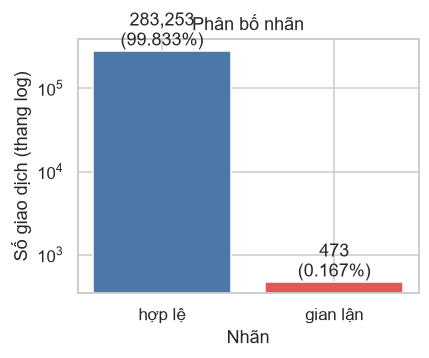

In [7]:
display(class_balance(df[TARGET]))

fig = plots.plot_class_balance(df[TARGET])
luu_hinh(
    fig, "01_class_balance.png",
    cau_hoi="Mất cân bằng đến mức nào, và nó buộc ta phải bỏ chỉ số nào?",
    tra_loi="1 trên 600. Accuracy 99,83% đạt được mà không cần mô hình nên bị loại; "
            "chỉ số chính là PR-AUC với đường cơ sở 0,00167.",
)

**Nhận xét.** Phải dùng thang log mới nhìn thấy cột lớp dương — bản thân việc đó đã là câu
trả lời. 473 mẫu gian lận so với 283.253 mẫu hợp lệ, tỷ lệ **1 : 600**.

Bốn hệ quả không thể thương lượng:

1. **Accuracy bị loại khỏi mọi bảng kết quả chính.** Đoán "hợp lệ" cho tất cả đạt ngay
   99,83% — cao hơn phần lớn mô hình nghiêm túc ở các bài toán cân bằng. Giai đoạn 2 sẽ huấn
   luyện đúng mô hình rỗng đó để đưa con số này vào báo cáo làm bằng chứng (T-17).
2. **Chỉ số chính là PR-AUC**, với đường cơ sở bằng đúng tỷ lệ lớp dương **0,00167**. Mô hình
   đạt PR-AUC 0,84 nghĩa là tốt hơn ngẫu nhiên khoảng 500 lần; con số 0,84 đứng một mình
   không nói lên điều đó.
3. **Mọi lần chia tập phải phân tầng.** `KFold` thường có thể sinh ra fold không chứa mẫu
   dương nào, lúc đó PR-AUC không định nghĩa được.
4. **Tập kiểm thử 20% chỉ có khoảng 95 mẫu gian lận.** Bắt hụt một mẫu là mất 1,05 điểm phần
   trăm recall. Vì vậy AC-M6 bắt buộc mọi chỉ số chính đi kèm khoảng tin cậy bootstrap — không
   có CI thì không phân biệt được cải tiến thật với dao động mẫu.

---
## 3. Hình 2 — Phân bố `Amount` theo lớp

> **Câu hỏi:** Gian lận tập trung ở khoảng tiền nào? `Amount` có tự nó phân biệt được không?

,hợp lệ,gian lận
phân vị 0%,0.00,0.00
phân vị 25%,5.67,1.00
phân vị 50%,22.00,9.82
phân vị 75%,77.46,105.89
phân vị 90%,203.00,348.65
phân vị 99%,1018.06,1364.14
phân vị 100%,25691.16,2125.87


Giao dịch ≤ 1 USD: 30,331 tổng, trong đó 171 gian lận → tỷ lệ 0.5638% (gấp 3.4 lần mức chung)
171/473 mẫu gian lận (36.2%) có số tiền ≤ 1 USD


đã lưu reports\figures\01_amount_distribution.png


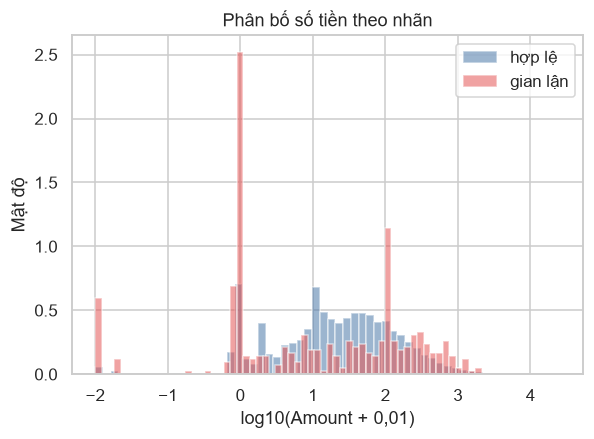

In [8]:
phan_vi = [0, 0.25, 0.5, 0.75, 0.90, 0.99, 1.0]
bang_amount = pd.DataFrame({
    plots.CLASS_LABELS[nhan]: df.loc[df[TARGET] == nhan, "Amount"].quantile(phan_vi)
    for nhan in (0, 1)
})
bang_amount.index = [f"phân vị {int(q * 100)}%" for q in phan_vi]
display(bang_amount.round(2))

nho = df["Amount"] <= 1
print(f"Giao dịch ≤ 1 USD: {int(nho.sum()):,} tổng, trong đó "
      f"{int(df.loc[nho, TARGET].sum())} gian lận → tỷ lệ {df.loc[nho, TARGET].mean():.4%} "
      f"(gấp {df.loc[nho, TARGET].mean() / ty_le_duong:.1f} lần mức chung)")
print(f"{int(df.loc[df[TARGET] == 1, 'Amount'].le(1).sum())}/{n_gian_lan} mẫu gian lận "
      f"({df.loc[df[TARGET] == 1, 'Amount'].le(1).mean():.1%}) có số tiền ≤ 1 USD")

fig = plots.plot_amount_distribution(df)
luu_hinh(
    fig, "01_amount_distribution.png",
    cau_hoi="Gian lận tập trung ở khoảng tiền nào? Amount có tự nó phân biệt được không?",
    tra_loi="Hai lớp chồng lấn gần như hoàn toàn; gian lận chỉ nhô lên ở vùng ≤ 1 USD "
            "(36% số vụ). Amount một mình không đủ, nhưng vùng tiền nhỏ là tín hiệu thật.",
)

**Nhận xét.** Hai phân bố **chồng lấn gần như hoàn toàn** trên toàn dải. Nếu kỳ vọng thấy gian
lận dồn vào các giao dịch giá trị lớn thì dữ liệu bác bỏ ngay: phân vị 99% của gian lận là
1.364 USD còn của hợp lệ là 1.018 USD — sát nhau; và giá trị lớn nhất của gian lận
(2.125,87 USD) còn **thấp hơn 12 lần** giá trị lớn nhất của giao dịch hợp lệ (25.691,16 USD).
Gian lận thẻ tín dụng ở đây không phải là những cú quẹt lớn.

Điểm nhô lên duy nhất nằm ở **đầu trái, vùng số tiền rất nhỏ**: 171 trong 473 vụ gian lận
(**36%**) có số tiền ≤ 1 USD, và trong nhóm ≤ 1 USD tỷ lệ gian lận là 0,564% — **gấp 3,4 lần**
mức chung. Đây là dấu vết của hành vi **thử thẻ**: kẻ gian quẹt một khoản rất nhỏ để xác nhận
thẻ còn sống trước khi dùng thật.

Kết luận cho thiết kế: `Amount` **không phải** đặc trưng phân biệt mạnh — notebook 02 sẽ cho
Cohen's d chỉ 0,14, mức "không đáng kể" — nhưng vẫn phải giữ trong mô hình, vì vùng tiền nhỏ
mang tín hiệu thật mà mô hình phi tuyến khai thác được. Toàn bộ sức mạnh phân biệt còn lại nằm
ở V1–V28; hình 5 và hình 6 sẽ xác nhận.

*Ghi chú kỹ thuật.* Trục hoành là `log10(Amount + 0,01)`. Cộng 0,01 để giữ lại các giao dịch
`Amount = 0` trên thang log thay vì âm thầm vứt chúng đi — chính nhóm đó là bằng chứng rõ nhất
của hành vi thử thẻ (xem hình 7).

---
## 4. Hình 3 — Tỷ lệ gian lận theo giờ

> **Câu hỏi:** Gian lận có dồn vào giờ vắng không? Nếu có thì `hour` đáng đưa vào mô hình.

 2h:  48/ 3,308 = 1.4510%   KTC95% [1.0962% – 1.9185%]   = 8.7× mức chung
10h:   8/16,548 = 0.0483%   KTC95% [0.0245% – 0.0954%]   = 0.3× mức chung

Khung 00–05h: 8.4% số giao dịch nhưng 24.3% số vụ gian lận (tỷ lệ 0.4823%)


,so_giao_dich,so_gian_lan,tỷ lệ,so với mức chung
hour,,,,
0,7647,6,0.0785%,0.47×
1,4208,10,0.2376%,1.43×
2,3308,48,1.4510%,8.70×
3,3487,17,0.4875%,2.92×
4,2204,23,1.0436%,6.26×
5,2988,11,0.3681%,2.21×
6,4082,9,0.2205%,1.32×
7,7233,23,0.3180%,1.91×
8,10232,9,0.0880%,0.53×


đã lưu reports\figures\01_hourly_fraud_rate.png


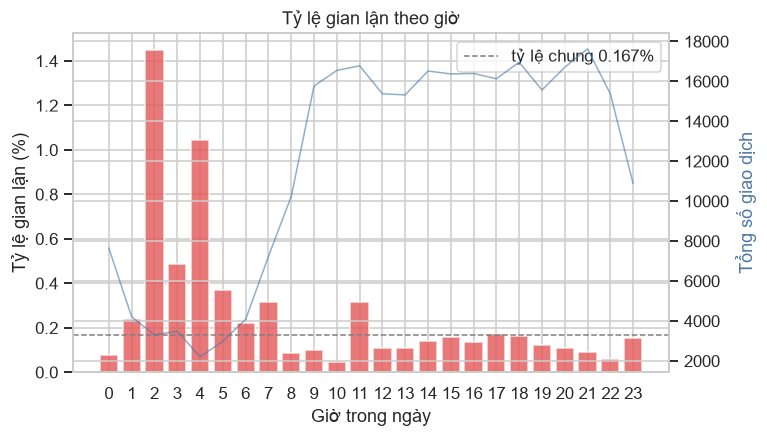

In [9]:
theo_gio = add_hour(df).groupby("hour")[TARGET].agg(so_giao_dich="size", so_gian_lan="sum")
theo_gio["tỷ lệ"] = theo_gio["so_gian_lan"] / theo_gio["so_giao_dich"]
theo_gio["so với mức chung"] = theo_gio["tỷ lệ"] / ty_le_duong


def wilson(k, n, z=1.96):
    # Khoảng tin cậy Wilson: dùng được khi k nhỏ, khác với công thức Wald thông thường.
    p = k / n
    mau = 1 + z**2 / n
    tam = (p + z**2 / (2 * n)) / mau
    nua = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / mau
    return tam - nua, tam + nua


for gio in (2, 10):
    hang = theo_gio.loc[gio]
    thap, cao = wilson(int(hang["so_gian_lan"]), int(hang["so_giao_dich"]))
    print(f"{gio:2d}h: {int(hang['so_gian_lan']):3d}/{int(hang['so_giao_dich']):6,} "
          f"= {hang['tỷ lệ']:.4%}   KTC95% [{thap:.4%} – {cao:.4%}]   "
          f"= {hang['so với mức chung']:.1f}× mức chung")

dem = theo_gio.loc[[0, 1, 2, 3, 4, 5]]
print()
print(f"Khung 00–05h: {dem['so_giao_dich'].sum() / n_dong:.1%} số giao dịch "
      f"nhưng {dem['so_gian_lan'].sum() / n_gian_lan:.1%} số vụ gian lận "
      f"(tỷ lệ {dem['so_gian_lan'].sum() / dem['so_giao_dich'].sum():.4%})")

display(theo_gio.style.format({"tỷ lệ": "{:.4%}", "so với mức chung": "{:.2f}×"})
        .background_gradient(subset=["tỷ lệ"], cmap="Reds"))

fig = plots.plot_hourly_rate(df)
luu_hinh(
    fig, "01_hourly_fraud_rate.png",
    cau_hoi="Gian lận có dồn vào giờ vắng không? hour có đáng đưa vào mô hình?",
    tra_loi="Có. 2h đạt 1,451% so với 0,048% lúc 10h — chênh 30 lần. Khung 00–05h chiếm "
            "8,4% giao dịch nhưng 24,3% số vụ. hour_sin/hour_cos có cơ sở thực nghiệm.",
)

**Nhận xét.** Đây là biểu đồ có giá trị nhất trong cả tám hình, vì nó trực tiếp biện minh cho
một quyết định sinh đặc trưng.

**Lúc 2 giờ sáng tỷ lệ gian lận là 1,451%** (48 trên 3.308 giao dịch), **lúc 10 giờ sáng chỉ
0,048%** (8 trên 16.548) — chênh nhau **30 lần**. So với mức chung 0,167%, giờ 2h cao gấp 8,7
lần còn giờ 10h thấp hơn 3,5 lần. Khoảng tin cậy Wilson 95% của hai giờ này là
[1,10% – 1,92%] và [0,025% – 0,095%], **không giao nhau** — chênh lệch không phải do ngẫu nhiên.

Đường màu xanh (số giao dịch, trục phải) cho thấy vì sao: 2 giờ sáng là vùng trũng của hoạt
động hợp lệ. Người thật ngủ, kẻ gian thì không. Gộp lại, **khung 00–05h chỉ chiếm 8,4% số giao
dịch nhưng gánh 24,3% số vụ gian lận**.

Ba hệ quả:

1. **`hour` được đưa vào mô hình, dưới dạng `hour_sin`/`hour_cos`** (02 §4). Mã hoá vòng tròn
   để 23h và 0h nằm kề nhau; nếu để số nguyên 0–23 thì mô hình tuyến tính coi hai mốc đó cách
   nhau 23 đơn vị, tức cắt ngang đúng khung giờ rủi ro nhất.
2. **`Time` thô thì không** (DS-03, ML-07). Nó là số giây kể từ giao dịch đầu tiên của một cửa
   sổ hai ngày cụ thể — mốc 86.400 không mang ý nghĩa nào ngoài bộ dữ liệu này. Chỉ *giờ trong
   ngày* mới lặp lại được khi triển khai.
3. **Đọc con số 1,451% một cách dè dặt.** Nó dựa trên 48 mẫu dương, và dữ liệu chỉ trải hai
   ngày tháng 9/2013 — "2 giờ sáng" ở đây là hai buổi đêm cụ thể, không phải một quy luật đã
   kiểm chứng qua nhiều mùa. Đây là một trong ba hạn chế bắt buộc nêu trong báo cáo (T-64).

---
## 5. Hình 4 — Ma trận tương quan giữa các đặc trưng

> **Câu hỏi:** V1–V28 có thực sự trực giao như PCA hứa hẹn không? Có phải lo đa cộng tuyến không?

Tương quan giữa các cặp V (bỏ đường chéo, 756 cặp có thứ tự):
  |r| lớn nhất       : 0.0189
  |r| trung bình     : 0.0023
  số cặp có |r| > 0,1: 0



Ngược lại, Amount tương quan rõ rệt với vài thành phần:


,r
V2,-0.533
V7,0.400
V5,-0.388
V20,0.341
V1,-0.230


đã lưu reports\figures\01_correlation_matrix.png


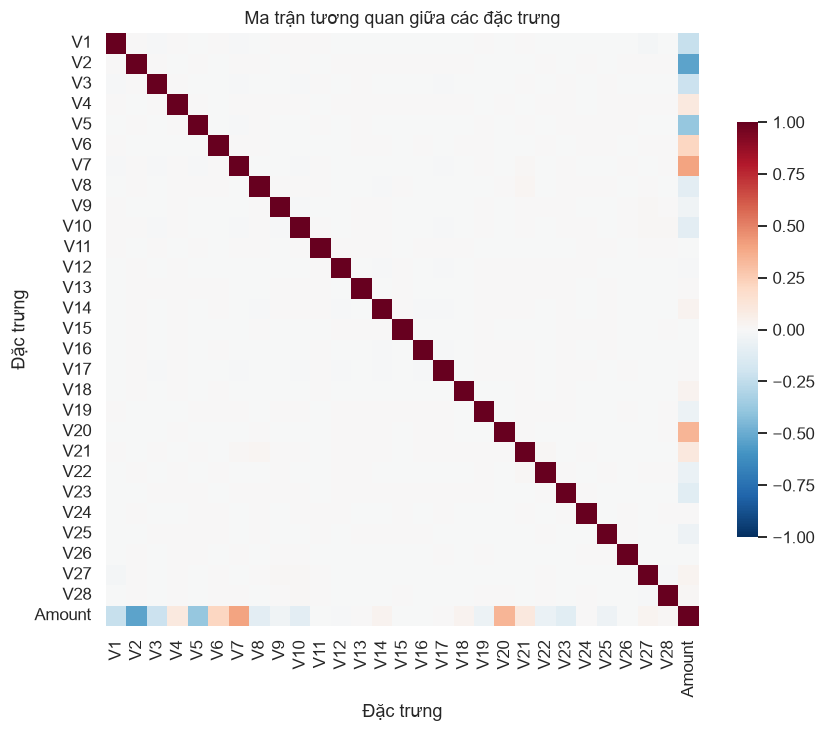

In [10]:
ma_tran_v = df[V_COLUMNS].corr().to_numpy()
ngoai_duong_cheo = ma_tran_v[~np.eye(len(V_COLUMNS), dtype=bool)]

print(f"Tương quan giữa các cặp V (bỏ đường chéo, {ngoai_duong_cheo.size} cặp có thứ tự):")
print(f"  |r| lớn nhất       : {np.abs(ngoai_duong_cheo).max():.4f}")
print(f"  |r| trung bình     : {np.abs(ngoai_duong_cheo).mean():.4f}")
print(f"  số cặp có |r| > 0,1: {int((np.abs(ngoai_duong_cheo) > 0.1).sum())}")

tuong_quan_amount = df[[*V_COLUMNS, "Amount"]].corr()["Amount"].drop("Amount")
print()
print("Ngược lại, Amount tương quan rõ rệt với vài thành phần:")
display(tuong_quan_amount.reindex(
    tuong_quan_amount.abs().sort_values(ascending=False).index).head(5).round(3).to_frame("r"))

fig = plots.plot_correlation_matrix(df)
luu_hinh(
    fig, "01_correlation_matrix.png",
    cau_hoi="V1–V28 có thực sự trực giao không? Có phải lo đa cộng tuyến không?",
    tra_loi="Trực giao trên thực tế: |r| lớn nhất giữa các cặp V chỉ 0,019. Không chạy PCA "
            "lại, không cần lọc đa cộng tuyến. Amount thì không nằm trong phép PCA đó.",
)

**Nhận xét.** Ma trận gần như trắng hoàn toàn ngoài đường chéo đỏ: **hệ số tương quan lớn nhất
giữa bất kỳ cặp `Vi`, `Vj` nào chỉ là 0,019**, trung bình 0,002, và **không cặp nào vượt 0,1**.
Đây đúng là thứ PCA bảo đảm — các thành phần chính trực giao theo cấu tạo — và việc nhìn thấy
nó xác nhận tệp tải về đúng là bản đã qua PCA như mô tả (DS-01).

Ba điều rút ra:

1. **Không chạy PCA lần nữa.** Chương giảm chiều được vận dụng ở chỗ *đọc hiểu* phép biến đổi
   đã có, không phải chồng thêm một phép nữa lên nó.
2. **Không cần bước lọc đa cộng tuyến**, và Logistic Regression không gặp vấn đề hệ số bất ổn
   định vì tương quan chéo.
3. **Không cần chuẩn hoá lại V1–V28.** Chúng đã cùng thang đo sau PCA. Bước tiền xử lý duy
   nhất là `RobustScaler` cho `Amount` (DS-02).

Chi tiết đáng chú ý: hàng và cột `Amount` **không** trắng — nó tương quan −0,53 với V2, +0,40
với V7, −0,39 với V5. Lý do là `Amount` **không nằm trong phép PCA**; nó được giữ nguyên bản
bên cạnh 28 thành phần. Điều đó nhắc rằng `Amount` là cột duy nhất trong tập đặc trưng còn giữ
đơn vị thật, và cần được đối xử riêng.

---
## 6. Hình 5 — Tương quan từng đặc trưng với nhãn

> **Câu hỏi:** Xếp hạng theo tương quan thô cho ta ứng viên nào — và có tin được thứ hạng đó không?

10 đặc trưng tương quan mạnh nhất với Class:


,Pearson r
V17,-0.3135
V14,-0.2934
V12,-0.2507
V10,-0.2070
V16,-0.1872
V3,-0.1823
V7,-0.1723
V11,0.1491
V4,0.1293
V18,-0.1053


|r| lớn nhất trên toàn bộ 29 đặc trưng: 0.3135 (V17)
số đặc trưng có |r| > 0,3: 1


đã lưu reports\figures\01_target_correlation.png


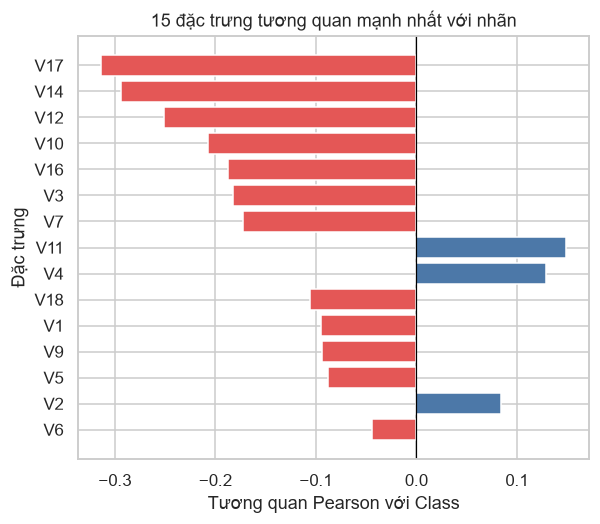

In [11]:
tuong_quan_nhan = df[[*V_COLUMNS, "Amount", TARGET]].corr()[TARGET].drop(TARGET)
xep_hang = tuong_quan_nhan.reindex(tuong_quan_nhan.abs().sort_values(ascending=False).index)

print("10 đặc trưng tương quan mạnh nhất với Class:")
display(xep_hang.head(10).round(4).to_frame("Pearson r"))
print(f"|r| lớn nhất trên toàn bộ 29 đặc trưng: {xep_hang.abs().max():.4f} "
      f"({xep_hang.abs().idxmax()})")
print(f"số đặc trưng có |r| > 0,3: {int((xep_hang.abs() > 0.3).sum())}")

fig = plots.plot_target_correlation(df, top_n=15)
luu_hinh(
    fig, "01_target_correlation.png",
    cau_hoi="Xếp hạng theo tương quan thô cho ứng viên nào, và có tin được thứ hạng đó không?",
    tra_loi="V17, V14, V12, V10 dẫn đầu, nhưng |r| lớn nhất chỉ 0,313. Độ LỚN của tương quan "
            "bị tỷ lệ lớp dương nén xuống nên không đọc được; chỉ thứ hạng là dùng được.",
)

**Nhận xét.** Thứ hạng thì hữu ích, còn **độ lớn thì gây hiểu nhầm nghiêm trọng**.

*Thứ hạng:* **V17 (−0,313), V14 (−0,293), V12 (−0,251), V10 (−0,207)** dẫn đầu, tất cả đều
mang dấu âm — giá trị thấp bất thường ở các thành phần này gắn với gian lận. Nhóm này sẽ xuất
hiện lại ở hình 6, ở bảng xếp hạng thống kê của notebook 02, và ở SHAP của notebook 07. Ba
phương pháp độc lập cùng chỉ vào một nhóm đặc trưng là tín hiệu đáng tin.

*Độ lớn:* **không một đặc trưng nào đạt |r| > 0,33**. Theo cách đọc quen thuộc ở lớp thống kê
cơ sở, r = 0,31 là "tương quan yếu", và kết luận sẽ là *không đặc trưng nào có quan hệ đáng kể
với nhãn*. Kết luận đó **sai**, và nó sai theo đúng cách mà accuracy 99,83% sai.

Lý do: tương quan điểm–nhị phân bị chính tỷ lệ lớp dương nén xuống. Với `p` là tỷ lệ lớp dương
và `q = 1 − p`, quan hệ giữa tương quan `r` và Cohen's d là

$$r = \frac{d}{\sqrt{d^{2} + 1/(p\,q)}}$$

Khi `p ≈ 0,00167` thì `1/(pq) ≈ 600`, áp đảo hoàn toàn `d²`, và `|r| ≈ |d|·√(pq) ≈ 0,041·|d|`.
Nói cách khác, **trần của |r| bị kéo xuống khoảng 0,041 lần effect size**: một đặc trưng tách
hai lớp bằng 8 độ lệch chuẩn cũng chỉ cho tương quan 0,31.

Notebook 02 chứng minh bằng số: **V17 có Cohen's d = −8,09**, một hiệu ứng khổng lồ, mà tương
quan Pearson của nó chỉ −0,313. Đây là lý do kỹ thuật vì sao FR-03 bắt buộc dùng kiểm định
thống kê kèm effect size thay vì đọc bảng tương quan.

---
## 7. Hình 6 — Mật độ hai lớp ở 6 đặc trưng phân tách mạnh nhất

> **Câu hỏi:** Chồng lấn thực tế đến đâu? Có đặc trưng đơn nào tách được hai lớp không?

Sáu đặc trưng mạnh nhất theo tương quan: V17, V14, V12, V10, V16, V3


,trung vị hợp lệ,trung vị gian lận,độ lệch chuẩn hợp lệ,độ lệch chuẩn gian lận,tỷ lệ độ lệch chuẩn
V17,-0.07,-5.16,0.75,6.97,9.31
V14,0.05,-6.59,0.89,4.25,4.76
V12,0.14,-5.44,0.95,4.58,4.85
V10,-0.09,-4.47,1.04,4.71,4.54
V16,0.07,-3.30,0.84,3.83,4.54
V3,0.18,-4.88,1.46,6.91,4.74


đã lưu reports\figures\01_feature_densities.png


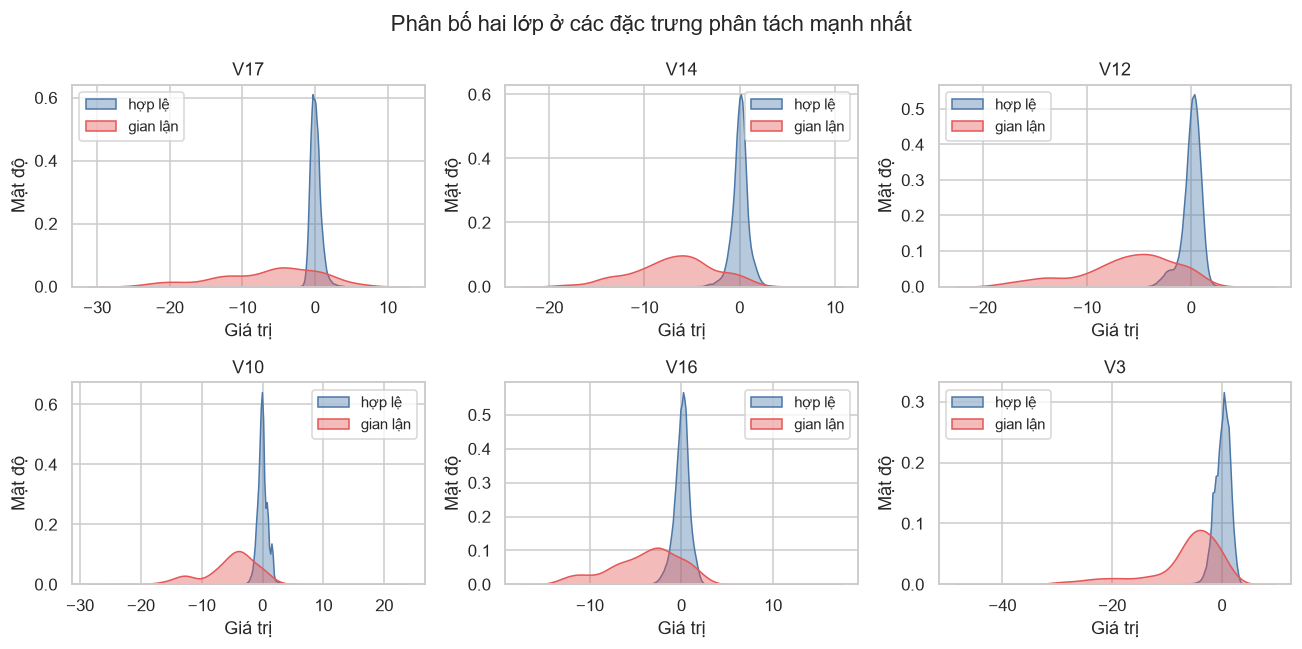

In [12]:
sau_dac_trung = list(xep_hang.index[:6])
print("Sáu đặc trưng mạnh nhất theo tương quan:", ", ".join(sau_dac_trung))

bang_mo_ta = pd.DataFrame({
    dac_trung: {
        "trung vị hợp lệ": df.loc[df[TARGET] == 0, dac_trung].median(),
        "trung vị gian lận": df.loc[df[TARGET] == 1, dac_trung].median(),
        "độ lệch chuẩn hợp lệ": df.loc[df[TARGET] == 0, dac_trung].std(),
        "độ lệch chuẩn gian lận": df.loc[df[TARGET] == 1, dac_trung].std(),
    }
    for dac_trung in sau_dac_trung
}).T
bang_mo_ta["tỷ lệ độ lệch chuẩn"] = (
    bang_mo_ta["độ lệch chuẩn gian lận"] / bang_mo_ta["độ lệch chuẩn hợp lệ"])
display(bang_mo_ta.round(2))

fig = plots.plot_feature_densities(df, features=sau_dac_trung)
luu_hinh(
    fig, "01_feature_densities.png",
    cau_hoi="Chồng lấn thực tế đến đâu? Có đặc trưng đơn nào tách được hai lớp không?",
    tra_loi="Không có đặc trưng đơn nào tách được: mọi cặp phân bố vẫn chồng lấn. Lớp gian "
            "lận dịch hẳn sang âm và bè rộng gấp 3–5 lần, nên cần mô hình nhiều biến.",
)

**Nhận xét.** Ở cả sáu ô, phân bố lớp gian lận **dịch hẳn sang phía âm** và **bè rộng hơn
nhiều** — độ lệch chuẩn của lớp gian lận gấp 3 đến 5 lần lớp hợp lệ. Lớp hợp lệ là một đỉnh
nhọn quanh 0, đúng như kỳ vọng cho thành phần chính đã chuẩn hoá; lớp gian lận thì trải rộng,
lệch, đôi chỗ hai đỉnh.

Nhưng **không ô nào cho thấy hai phân bố tách rời**. Ở mọi đặc trưng vẫn tồn tại vùng chồng
lấn đáng kể, và vùng đó chứa gần như toàn bộ 283.253 giao dịch hợp lệ. Với tỷ lệ 1:600, kể cả
một ngưỡng cắt rất tốt trên một biến đơn cũng kéo theo hàng nghìn cảnh báo giả.

Ba kết luận:

1. **Không tồn tại quy tắc một biến.** Bài toán cần mô hình khai thác *tổ hợp* nhiều đặc trưng
   — đó là lý do chọn họ cây tăng cường (XGBoost, LightGBM) ở giai đoạn 3–4.
2. **Khác biệt nằm ở phương sai nhiều ngang với ở trung bình.** Gian lận không chỉ "thấp hơn"
   mà còn "bất thường hơn". Cohen's d chỉ đo chênh lệch trung bình nên bỏ sót phần này; đó là
   lý do notebook 02 tính thêm Cliff's delta, một chỉ số dựa trên thứ hạng.
3. **V1–V28 là thành phần PCA nên không diễn giải được về nghiệp vụ.** Ta chỉ được nói "V14
   thấp bất thường gắn với gian lận", **không được** nói "V14 là số lần giao dịch nước ngoài".
   Chú thích này phải cố định trong giao diện (UI-02) và trong báo cáo (T-33, T-64).

---
## 8. Hình 7 — Hộp `Amount` theo lớp

> **Câu hỏi:** Trung vị và ngoại lai của số tiền khác nhau thế nào, và điều đó đổi gì trong tiền xử lý?

,số_lượng,trung_vị,trung_bình,độ_lệch_chuẩn,lớn_nhất
hợp lệ,283253,22.00,88.41,250.38,25691.16
gian lận,473,9.82,123.87,260.21,2125.87


Giao dịch có Amount = 0: 1,808 tổng, trong đó 25 là gian lận
  tỷ lệ gian lận trong nhóm này: 1.3827% (gấp 8.3 lần mức chung)

Nghịch lý trung vị / trung bình:
  trung vị  : gian lận   9.82  <  hợp lệ  22.00
  trung bình: gian lận 123.87  >  hợp lệ  88.41


đã lưu reports\figures\01_amount_boxplot.png


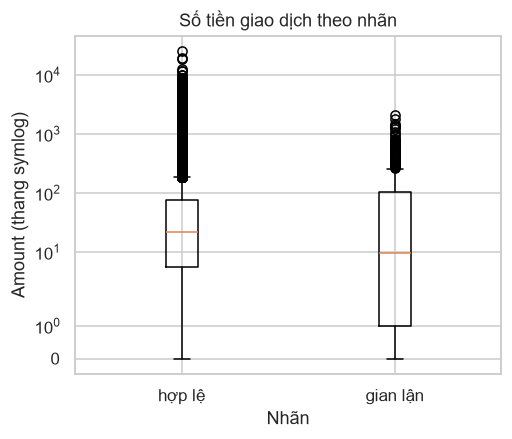

In [13]:
thong_ke_amount = df.groupby(TARGET)["Amount"].agg(
    số_lượng="count", trung_vị="median", trung_bình="mean",
    độ_lệch_chuẩn="std", lớn_nhất="max")
thong_ke_amount.index = [plots.CLASS_LABELS[i] for i in thong_ke_amount.index]
display(thong_ke_amount.round(2))

khong_dong = df["Amount"] == 0
print(f"Giao dịch có Amount = 0: {int(khong_dong.sum()):,} tổng, "
      f"trong đó {int(df.loc[khong_dong, TARGET].sum())} là gian lận")
print(f"  tỷ lệ gian lận trong nhóm này: {df.loc[khong_dong, TARGET].mean():.4%} "
      f"(gấp {df.loc[khong_dong, TARGET].mean() / ty_le_duong:.1f} lần mức chung)")

trung_vi = thong_ke_amount["trung_vị"]
trung_binh = thong_ke_amount["trung_bình"]
print()
print("Nghịch lý trung vị / trung bình:")
print(f"  trung vị  : gian lận {trung_vi.iloc[1]:6.2f}  <  hợp lệ {trung_vi.iloc[0]:6.2f}")
print(f"  trung bình: gian lận {trung_binh.iloc[1]:6.2f}  >  hợp lệ {trung_binh.iloc[0]:6.2f}")

fig = plots.plot_amount_boxplot(df)
luu_hinh(
    fig, "01_amount_boxplot.png",
    cau_hoi="Trung vị và ngoại lai của số tiền khác nhau thế nào, đổi gì trong tiền xử lý?",
    tra_loi="Trung vị gian lận 9,82 THẤP hơn hợp lệ 22,00 nhưng trung bình lại CAO hơn "
            "(123,87 so với 88,41). Đuôi dày hai phía nên bắt buộc RobustScaler.",
)

**Nhận xét.** Hình này chứa nghịch lý quan trọng nhất về `Amount`:

| | trung vị | trung bình |
|---|---|---|
| hợp lệ | 22,00 | 88,41 |
| gian lận | **9,82** | **123,87** |

**Trung vị của gian lận thấp hơn hợp lệ (9,82 so với 22,00), nhưng trung bình lại cao hơn
(123,87 so với 88,41).** Hai chỉ số trả lời ngược nhau về cùng một câu hỏi. Nguyên nhân: phân
bố gian lận có đuôi dày ở **cả hai đầu** — một cụm rất nhỏ ở vùng thử thẻ kéo trung vị xuống,
một đuôi phải kéo trung bình lên. Báo cáo chỉ nêu một trong hai con số sẽ dựng nên bức tranh
sai, nên **phải nêu cả hai**.

**25 giao dịch gian lận có `Amount = 0`.** Trong nhóm 1.808 giao dịch không đồng, tỷ lệ gian
lận là 1,383% — **gấp 8,3 lần** mức chung. Đây không phải dữ liệu hỏng cần làm sạch mà là
**tín hiệu có thật**: kiểm tra thẻ còn hiệu lực bằng một khoản quẹt 0 đồng. 02 §6 nói rõ giữ
nguyên nhóm này. *(Trên dữ liệu thô con số là 27 giao dịch; 2 trong đó là dòng trùng lặp.)*

**Hệ quả cho tiền xử lý (DS-02).** Với trung vị 22 mà giá trị lớn nhất 25.691, `StandardScaler`
sẽ để vài trăm ngoại lai kéo lệch cả trung bình lẫn độ lệch chuẩn, ép phần lớn dữ liệu vào một
dải hẹp quanh 0. **`RobustScaler` (trung vị và IQR) là lựa chọn bắt buộc**, và nó phải nằm
**trong pipeline** để chỉ học thống kê của tập huấn luyện trong từng fold (ML-04) — nếu fit
trên toàn bộ dữ liệu trước khi chia tập thì trung vị và IQR của tập kiểm thử đã rò rỉ vào bước
huấn luyện.

---
## 9. Hình 8 — Chiếu t-SNE trên mẫu con cân bằng

> **Câu hỏi:** Gian lận có tách thành cụm trong không gian 28 chiều không? Bài toán có khả thi không?

Lấy mẫu con vì hai lý do: t-SNE trên 284.000 điểm là bất khả thi về thời gian, và ngay cả khi
chạy được thì 473 điểm dương cũng chìm hoàn toàn. Mẫu con gồm **toàn bộ 473 mẫu gian lận** và
**2.000 mẫu hợp lệ lấy ngẫu nhiên** với `random_state=42`.

Độ thuần khiết 10 láng giềng gần nhất (trong mẫu con cân bằng):
  trung vị của mẫu gian lận        : 1.00
  có ≥ 50% láng giềng là gian lận  : 85.8% (406/473)
  KHÔNG có láng giềng gian lận nào : 4.4% (21/473)


đã lưu reports\figures\01_tsne_projection.png


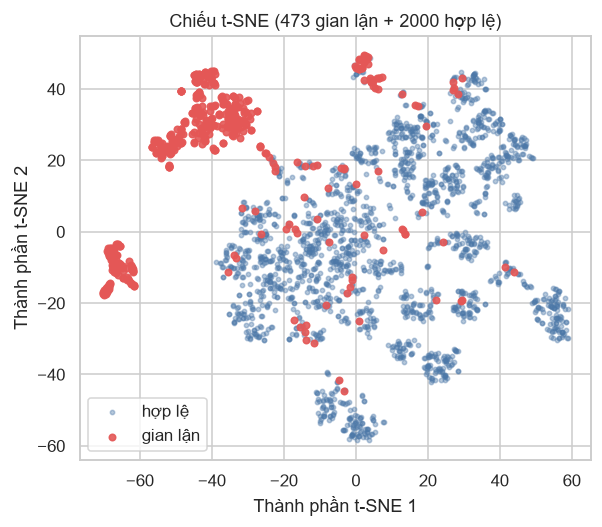

In [14]:
from sklearn.neighbors import NearestNeighbors

gian_lan = df[df[TARGET] == 1]
hop_le = df[df[TARGET] == 0].sample(n=2000, random_state=RANDOM_STATE)
mau_con = pd.concat([gian_lan, hop_le])

# Đo độ tách cụm bằng số, trong KHÔNG GIAN GỐC 28 chiều — không đo trên toạ độ t-SNE,
# vì t-SNE không bảo toàn khoảng cách nên mọi con số đọc từ hình đều không đáng tin.
X = mau_con[V_COLUMNS].to_numpy()
y = mau_con[TARGET].to_numpy()
_, chi_so = NearestNeighbors(n_neighbors=11).fit(X).kneighbors(X)
do_thuan_khiet = y[chi_so[:, 1:]].mean(axis=1)   # bỏ cột 0 vì đó là chính điểm đang xét

tk_gian_lan = do_thuan_khiet[y == 1]
print("Độ thuần khiết 10 láng giềng gần nhất (trong mẫu con cân bằng):")
print(f"  trung vị của mẫu gian lận        : {np.median(tk_gian_lan):.2f}")
print(f"  có ≥ 50% láng giềng là gian lận  : {(tk_gian_lan >= 0.5).mean():.1%} "
      f"({int((tk_gian_lan >= 0.5).sum())}/{len(tk_gian_lan)})")
print(f"  KHÔNG có láng giềng gian lận nào : {(tk_gian_lan == 0).mean():.1%} "
      f"({int((tk_gian_lan == 0).sum())}/{len(tk_gian_lan)})")

fig = plots.plot_projection(df, n_negative=2000, random_state=RANDOM_STATE)
luu_hinh(
    fig, "01_tsne_projection.png",
    cau_hoi="Gian lận có tách thành cụm trong không gian 28 chiều không? Bài toán khả thi không?",
    tra_loi="Có. 85,8% mẫu gian lận có đa số láng giềng cùng lớp, và hình cho thấy 2–3 cụm đỏ "
            "tách hẳn. 4,4% (21 mẫu) nằm lẫn hoàn toàn — đó là nhóm FN sẽ gặp ở giai đoạn 5.",
)

**Nhận xét.** Hình cho thấy **hai đến ba cụm đỏ tách hẳn** khỏi đám mây xanh: một cụm lớn phía
trên bên trái, một cụm nhỏ tách rời hẳn ở dưới bên trái, và một nhóm nhỏ ở đỉnh giữa. Phần còn
lại của lớp gian lận nằm rải rác bên trong vùng hợp lệ.

Con số xác nhận ấn tượng thị giác, và được đo **trong không gian gốc 28 chiều** chứ không đo
trên toạ độ t-SNE: **85,8% mẫu gian lận có ít nhất một nửa trong 10 láng giềng gần nhất cũng
là gian lận**, dù mẫu con chỉ có 19% là gian lận. Trung vị độ thuần khiết bằng 1,0 — quá nửa
số mẫu gian lận có **cả 10** láng giềng đều là gian lận.

Hai kết luận trái chiều, cả hai đều cần cho việc lập kế hoạch:

- **Bài toán khả thi.** Gian lận không nằm ngẫu nhiên trong không gian đặc trưng; nó có cấu
  trúc cục bộ rõ ràng. Dải PR-AUC kỳ vọng 0,80–0,87 ở
  [04 §3.4](../docs/04-thiet-ke-mo-hinh-ml.md) là hợp lý. Cấu trúc cục bộ đậm cũng giải thích
  trước vì sao SMOTE — vốn nội suy giữa các láng giềng cùng lớp — sẽ sinh ra mẫu tổng hợp
  tương đối hợp lý ở đây (giai đoạn 3).
- **Có một trần không vượt qua được.** **4,4% mẫu gian lận (21 trong 473) không có một láng
  giềng gian lận nào.** Chúng nằm lọt thỏm giữa các giao dịch hợp lệ và hầu như không đặc
  trưng nào phân biệt được. Đây chính là nhóm sẽ thành âm tính giả ở giai đoạn 5, và là lý do
  recall 100% không phải mục tiêu thực tế — AC-M2 đặt ngưỡng ở 0,75.

**Cảnh báo khi đọc hình.** t-SNE **không bảo toàn khoảng cách toàn cục**. Được phép đọc "có
cụm hay không có cụm"; **không** được đọc khoảng cách giữa hai cụm, kích thước tương đối của
cụm, hay mật độ. Hình này trả lời một câu hỏi nhị phân về tính khả thi, không phải để đo đạc.

---
## 10. Kiểm tra điều kiện hoàn thành

Ô dưới kiểm **bằng máy** các điều kiện *xong là khi* của T-12 và T-13, thay vì tự nhận là đã xong:

- **T-12** — đủ 8 tệp PNG tiền tố `01_` trong `reports/figures/`, mỗi hình có tiêu đề và nhãn
  hai trục.
- **T-13** — không hình nào bị bỏ trống nhận xét.

In [15]:
def la_truc_phu(fig, ax):
    # Trục sinh bởi twinx() dùng chung trục hoành với một ô con đứng trước nó.
    anh_em = ax.get_shared_x_axes().get_siblings(ax)
    if len(anh_em) <= 1:
        return False
    thu_tu = fig.axes.index(ax)
    return any(fig.axes.index(khac) < thu_tu for khac in anh_em if khac is not ax)


def kiem_tra_nhan(fig):
    # Hình có tiêu đề chưa, và mọi ô con có dữ liệu đã đủ nhãn hai trục chưa?
    # Hai loại trục được miễn: thanh màu của heatmap (không phải ô dữ liệu), và
    # trục phụ của twinx() — trục hoành nó dùng chung với trục chính nên để trống mới đúng.
    o_con = [ax for ax in fig.axes
             if ax.get_visible() and ax.has_data() and ax.get_label() != "<colorbar>"]
    truc_chinh = [ax for ax in o_con if not la_truc_phu(fig, ax)]

    co_tieu_de = bool(fig.get_suptitle()) or any(ax.get_title() for ax in o_con)
    co_nhan_x = all(bool(ax.get_xlabel()) for ax in truc_chinh)
    co_nhan_y = all(bool(ax.get_ylabel()) for ax in o_con)
    return co_tieu_de, co_nhan_x, co_nhan_y


hang = []
for ten_tep, muc in SO_GHI_HINH.items():
    tieu_de, nhan_x, nhan_y = kiem_tra_nhan(muc["fig"])
    duong_dan = FIGURES_DIR / ten_tep
    hang.append({
        "tệp": ten_tep,
        "tồn tại": duong_dan.exists(),
        "KB": round(duong_dan.stat().st_size / 1024) if duong_dan.exists() else 0,
        "tiêu đề": tieu_de,
        "nhãn trục x": nhan_x,
        "nhãn trục y": nhan_y,
        "có nhận xét": bool(muc["cau_hoi"]) and bool(muc["tra_loi"]),
    })

kiem_tra = pd.DataFrame(hang)
display(kiem_tra)

tren_dia = sorted(p.name for p in FIGURES_DIR.glob("01_*.png"))
print(f"Tệp 01_*.png thực có trên đĩa: {len(tren_dia)}")
for ten in tren_dia:
    print("   ", ten)

assert len(tren_dia) == 8, f"T-12 cần đúng 8 hình, đang có {len(tren_dia)}"
assert set(tren_dia) == set(SO_GHI_HINH), "tệp trên đĩa không khớp sổ ghi hình"
assert kiem_tra["tồn tại"].all(), "có hình chưa ghi được ra đĩa"
assert kiem_tra["tiêu đề"].all(), "có hình thiếu tiêu đề (T-12)"
assert kiem_tra["nhãn trục x"].all(), "có hình thiếu nhãn trục hoành (T-12)"
assert kiem_tra["nhãn trục y"].all(), "có hình thiếu nhãn trục tung (T-12)"
assert kiem_tra["có nhận xét"].all(), "có hình bị bỏ trống nhận xét (T-13)"

print()
print("T-12 đạt: đủ 8 hình, hình nào cũng có tiêu đề và nhãn hai trục.")
print("T-13 đạt: hình nào cũng có câu hỏi và câu trả lời kèm theo.")

,tệp,tồn tại,KB,tiêu đề,nhãn trục x,nhãn trục y,có nhận xét
0,01_class_balance.png,True,25,True,True,True,True
1,01_amount_distribution.png,True,30,True,True,True,True
2,01_hourly_fraud_rate.png,True,73,True,True,True,True
3,01_correlation_matrix.png,True,81,True,True,True,True
4,01_target_correlation.png,True,37,True,True,True,True
5,01_feature_densities.png,True,125,True,True,True,True
6,01_amount_boxplot.png,True,26,True,True,True,True
7,01_tsne_projection.png,True,175,True,True,True,True


Tệp 01_*.png thực có trên đĩa: 8
    01_amount_boxplot.png
    01_amount_distribution.png
    01_class_balance.png
    01_correlation_matrix.png
    01_feature_densities.png
    01_hourly_fraud_rate.png
    01_target_correlation.png
    01_tsne_projection.png

T-12 đạt: đủ 8 hình, hình nào cũng có tiêu đề và nhãn hai trục.
T-13 đạt: hình nào cũng có câu hỏi và câu trả lời kèm theo.


In [16]:
print("Tám câu hỏi và tám câu trả lời")
print("=" * 80)
for thu_tu, (ten_tep, muc) in enumerate(SO_GHI_HINH.items(), start=1):
    print()
    print(f"[{thu_tu}] {ten_tep}")
    print(f"    Hỏi: {muc['cau_hoi']}")
    print(f"    Đáp: {muc['tra_loi']}")

Tám câu hỏi và tám câu trả lời

[1] 01_class_balance.png
    Hỏi: Mất cân bằng đến mức nào, và nó buộc ta phải bỏ chỉ số nào?
    Đáp: 1 trên 600. Accuracy 99,83% đạt được mà không cần mô hình nên bị loại; chỉ số chính là PR-AUC với đường cơ sở 0,00167.

[2] 01_amount_distribution.png
    Hỏi: Gian lận tập trung ở khoảng tiền nào? Amount có tự nó phân biệt được không?
    Đáp: Hai lớp chồng lấn gần như hoàn toàn; gian lận chỉ nhô lên ở vùng ≤ 1 USD (36% số vụ). Amount một mình không đủ, nhưng vùng tiền nhỏ là tín hiệu thật.

[3] 01_hourly_fraud_rate.png
    Hỏi: Gian lận có dồn vào giờ vắng không? hour có đáng đưa vào mô hình?
    Đáp: Có. 2h đạt 1,451% so với 0,048% lúc 10h — chênh 30 lần. Khung 00–05h chiếm 8,4% giao dịch nhưng 24,3% số vụ. hour_sin/hour_cos có cơ sở thực nghiệm.

[4] 01_correlation_matrix.png
    Hỏi: V1–V28 có thực sự trực giao không? Có phải lo đa cộng tuyến không?
    Đáp: Trực giao trên thực tế: |r| lớn nhất giữa các cặp V chỉ 0,019. Không chạy PCA lại, không cầ

---
## 11. Chốt lại

**Bảy con số mang sang giai đoạn sau**

| Con số | Giá trị | Dùng ở đâu |
|---|---|---|
| Dòng sau khi loại trùng lặp | 283.726 (473 gian lận, 0,167%) | mọi bảng kết quả |
| Trùng lặp đã loại | 1.081 dòng, 19 gian lận | báo cáo, mục dữ liệu |
| Accuracy của mô hình rỗng | 99,833% | T-17, bằng chứng cho G-2 |
| Đường cơ sở PR-AUC | 0,00167 | mọi hình PR (T-21) |
| Mẫu dương trong tập kiểm thử | khoảng 95 | T-16, biện minh cho bootstrap CI |
| Tỷ lệ gian lận 2h so với 10h | 1,451% so với 0,048% | biện minh `hour_sin`/`hour_cos` |
| Sáu đặc trưng mạnh nhất | V17, V14, V12, V10, V16, V3 | đối chiếu với SHAP ở T-32 |

**Bốn quyết định thiết kế mà EDA này biện minh**

1. **Bỏ accuracy, lấy PR-AUC làm chỉ số chính** — hình 1.
2. **Đưa `hour` vào dưới dạng sin/cos, bỏ `Time` thô** — hình 3 (DS-03, ML-07).
3. **`RobustScaler` cho `Amount`, đặt trong pipeline** — hình 7 (DS-02, ML-04).
4. **Không chạy PCA lại, không lọc đa cộng tuyến** — hình 4 (DS-01).

**Ba điều chưa biết, để lại cho notebook sau**

- Tương quan thô nén độ lớn xuống dưới 0,33 nên không đọc được → **notebook 02** thay bằng
  Mann–Whitney U và effect size.
- 4,4% mẫu gian lận không có láng giềng cùng lớp → **giai đoạn 5** soi chúng bằng SHAP (T-33).
- Cấu trúc cụm cục bộ gợi ý SMOTE sẽ sinh mẫu hợp lý → **giai đoạn 3** kiểm chứng bằng số
  (T-20, T-22).

**Việc tiếp theo:** [`02_statistics.ipynb`](02_statistics.ipynb) — Mann–Whitney U cho 30 đặc
trưng, hiệu chỉnh Benjamini–Hochberg, Cohen's d và Cliff's delta, xuất
`reports/feature_ranking.csv`.